In [1]:
!pip install mediapipe==0.10.21 opencv-python flask flask-cors imutils scipy scikit-learn matplotlib seaborn tensorflow ultralytics dlib-bin

print("\n" + "="*62)
print("setelah cell ini berhasil di run, klik menu")
print("Runtime  ->  Restart session")
print("lalu jalankan ulang notebook dari Cell 1.")
print("Wajib agar MediaPipe 0.10.21 yang dipakai,")
print("bukan versi bawaan Colab 0.10.35 yang sudah tidak punya solutions.")
print("="*62)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━


setelah cell ini berhasil di run, klik menu
Runtime  ->  Restart session
lalu jalankan ulang notebook dari Cell 1.
Wajib agar MediaPipe 0.10.21 yang dipakai,
bukan versi bawaan Colab 0.10.35 yang sudah tidak punya solutions.


In [1]:
import os
import mediapipe as mp
print(f"File mediapipe berasal dari: {mp.__file__}")
print(f"Isi folder saat ini: {os.listdir('.')}")

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


File mediapipe berasal dari: /usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py
Isi folder saat ini: ['.config', 'sample_data']


In [2]:
import os, zipfile, shutil, random, time, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import deque
from pathlib import Path
from scipy.spatial import distance as dist

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.19.1
OpenCV: 4.11.0
GPU Available: True


Mounted at /content/drive
 Dataset extracted.
 Raw train dir: /content/dataset_raw/imagedatasetdriver/train

 Distribusi Dataset:
   Closed      : 726 images
   Open        : 726 images
   yawn        : 723 images
   no_yawn     : 725 images
   TOTAL       : 2900 images


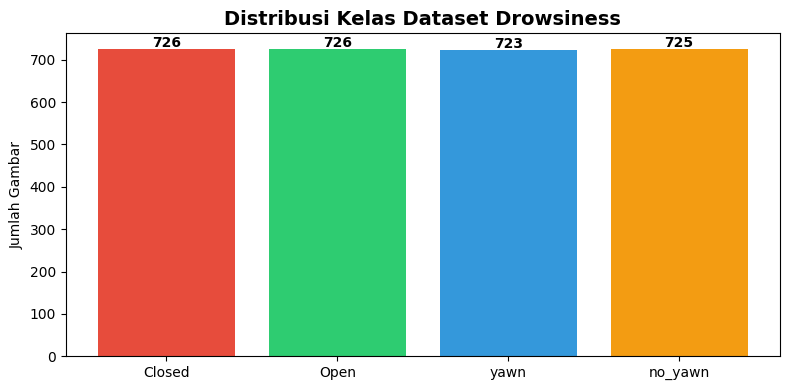

 Distribusi dataset ditampilkan.


In [3]:
# CELL 3

import os, zipfile, glob
from google.colab import drive

try:
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print("   Mount pertama gagal, mencoba lagi:", e)
    drive.mount('/content/drive', force_remount=True)

EXTRACT_DIR = '/content/dataset_raw'
DATASET_DIR = '/content/dataset_split'

ZIP_PATH = '/content/drive/MyDrive/Colab Notebooks/RM/imagedatasetdriver.zip'

if not os.path.exists(ZIP_PATH):
    print(f"Tidak ada di {ZIP_PATH}\nMencari 'imagedatasetdriver.zip' di Drive...")
    matches = glob.glob('/content/drive/MyDrive/**/imagedatasetdriver.zip', recursive=True)
    if matches:
        ZIP_PATH = matches[0]
        print(f" Ketemu di: {ZIP_PATH}")

assert os.path.exists(ZIP_PATH), (
    "\n imagedatasetdriver.zip TIDAK ditemukan di Google Drive.\n"
    "   Upload dulu file zip ke Drive\n"
    "   Lalu jalankan ulang cell ini."
)

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print(" Dataset extracted.")
else:
    print(" Dataset already extracted.")

RAW_TRAIN = None
for root, dirs, fnames in os.walk(EXTRACT_DIR):
    if set(dirs) & {'Closed', 'Open', 'yawn', 'no_yawn'}:
        RAW_TRAIN = root
        break
print(f" Raw train dir: {RAW_TRAIN}")
assert RAW_TRAIN is not None, " Folder kelas (Closed/Open/yawn/no_yawn) tidak ketemu dalam zip."

CLASSES = ['Closed', 'Open', 'yawn', 'no_yawn']
CLASS_LABELS = {cls: idx for idx, cls in enumerate(CLASSES)}

import matplotlib.pyplot as plt
print("\n Distribusi Dataset:")
total = 0; class_counts = {}
for cls in CLASSES:
    cls_path = os.path.join(RAW_TRAIN, cls)
    count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    class_counts[cls] = count; total += count
    print(f"   {cls:12s}: {count} images")
print(f"   {'TOTAL':12s}: {total} images")

plt.figure(figsize=(8,4))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=['#e74c3c','#2ecc71','#3498db','#f39c12'])
for bar, val in zip(bars, class_counts.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(val),
             ha='center', fontweight='bold')
plt.title('Distribusi Kelas Dataset Drowsiness', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Gambar'); plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150); plt.show()
print(" Distribusi dataset ditampilkan.")


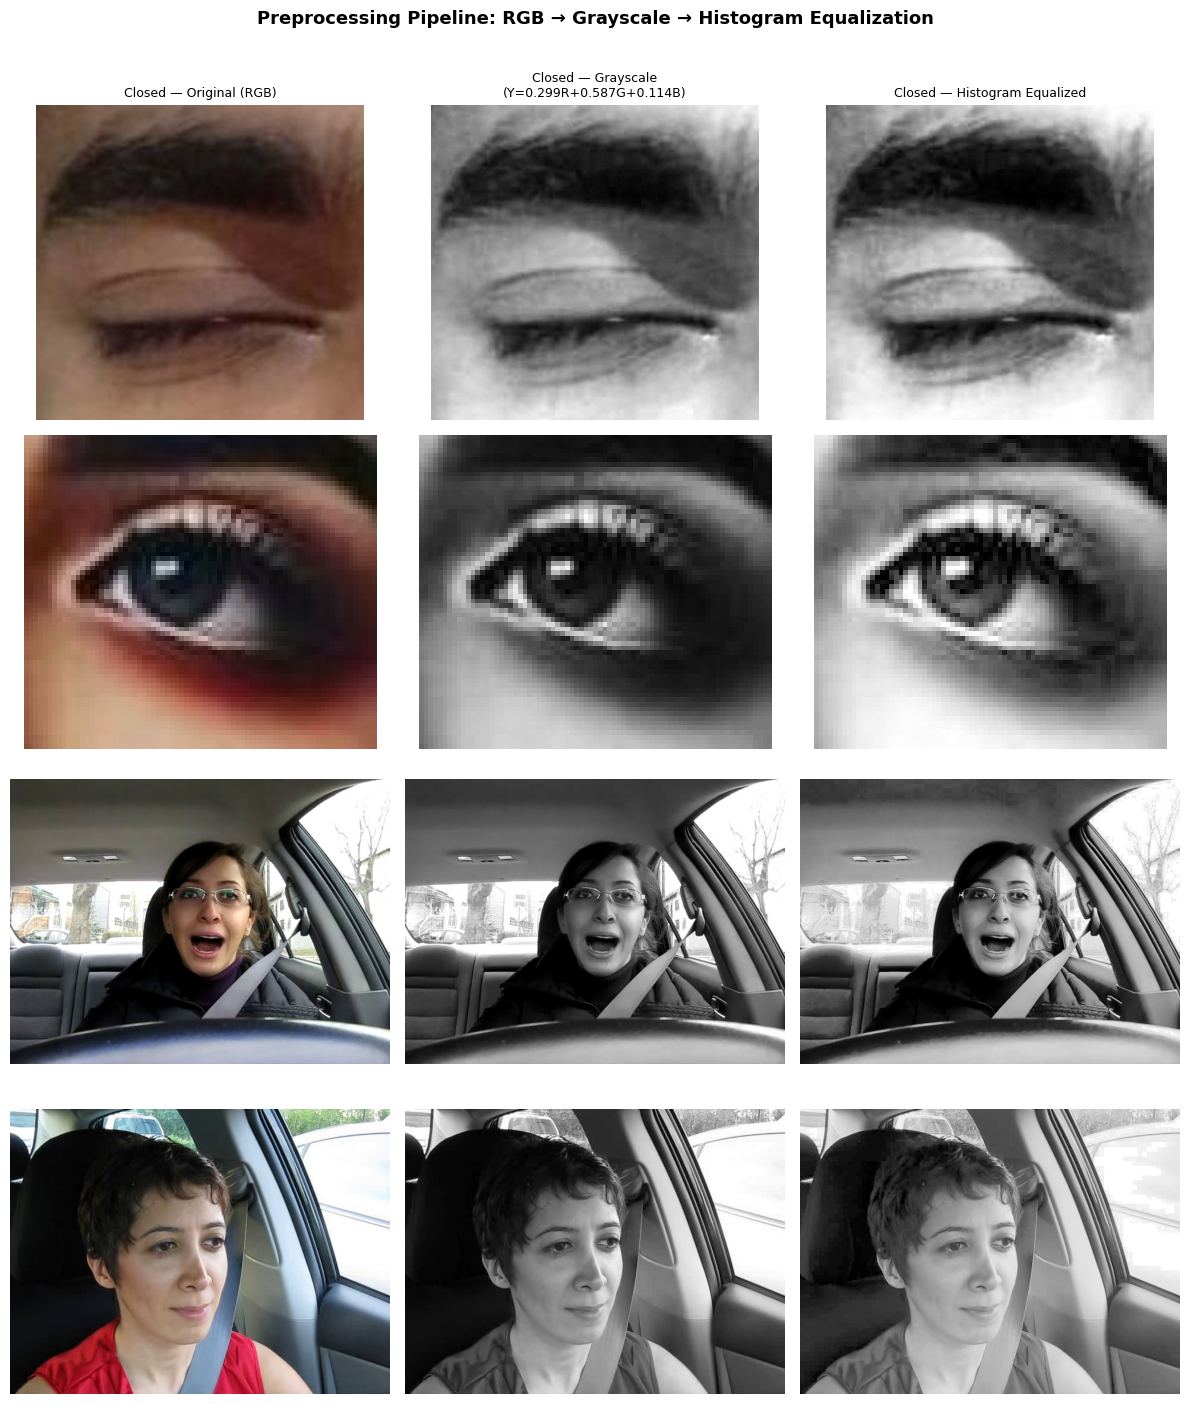

 Visualisasi preprocessing selesai.


In [4]:
# CELL 4: Preprocessing Pipeline
# Formula: Y = 0.299R + 0.587G + 0.114B (per paper)
# + Histogram Equalization via CDF

IMG_SIZE = (64, 64)

def preprocess_image(img_path=None, img_array=None, return_gray=True):
    if img_path is not None:
        img = cv2.imread(img_path)
        if img is None:
            return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = img_array.copy()

    if len(img.shape) == 3:
        gray = (0.299 * img[:,:,0] +
                0.587 * img[:,:,1] +
                0.114 * img[:,:,2]).astype(np.uint8)
    else:
        gray = img.astype(np.uint8)

    hist, bins = np.histogram(gray.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_min = cdf[cdf > 0].min()
    N = gray.size
    equalized = np.round(((cdf[gray] - cdf_min) / (N - cdf_min)) * 255).astype(np.uint8)

    resized = cv2.resize(equalized, IMG_SIZE)

    if return_gray:
        return resized
    else:
        return cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)


sample_images = {}
for cls in CLASSES:
    cls_path = os.path.join(RAW_TRAIN, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith('.jpg')]
    sample_images[cls] = os.path.join(cls_path, files[0])

fig, axes = plt.subplots(len(CLASSES), 3, figsize=(12, 14))
titles = ['Original (RGB)', 'Grayscale\n(Y=0.299R+0.587G+0.114B)', 'Histogram Equalized']

for row, cls in enumerate(CLASSES):
    img_bgr = cv2.imread(sample_images[cls])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    gray = (0.299 * img_rgb[:,:,0] +
            0.587 * img_rgb[:,:,1] +
            0.114 * img_rgb[:,:,2]).astype(np.uint8)

    hist, _ = np.histogram(gray.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_min = cdf[cdf > 0].min()
    equalized = np.round(((cdf[gray] - cdf_min) / (gray.size - cdf_min)) * 255).astype(np.uint8)

    for col, (image, cmap) in enumerate([(img_rgb, None), (gray, 'gray'), (equalized, 'gray')]):
        axes[row, col].imshow(image, cmap=cmap)
        axes[row, col].set_title(f'{cls} — {titles[col]}' if row == 0 else '', fontsize=9)
        axes[row, col].set_ylabel(cls if col == 0 else '', fontsize=10, fontweight='bold')
        axes[row, col].axis('off')

plt.suptitle('Preprocessing Pipeline: RGB → Grayscale → Histogram Equalization',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('preprocessing_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisasi preprocessing selesai.")

In [5]:
# CELL 5: Data Splitting — Stratified 70/15/15

def create_split_dirs(base_dir, splits=['train','val','test'], classes=CLASSES):
    for split in splits:
        for cls in classes:
            os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

def split_dataset(raw_train_dir, output_dir, train_r=0.70, val_r=0.15, test_r=0.15, seed=42):
    random.seed(seed)
    create_split_dirs(output_dir)

    split_summary = {'train': {}, 'val': {}, 'test': {}}

    for cls in CLASSES:
        src_dir = os.path.join(raw_train_dir, cls)
        files = sorted([f for f in os.listdir(src_dir)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))])
        random.shuffle(files)

        n = len(files)
        n_train = int(n * train_r)
        n_val   = int(n * val_r)

        splits_map = {
            'train': files[:n_train],
            'val'  : files[n_train : n_train + n_val],
            'test' : files[n_train + n_val:]
        }

        for split, flist in splits_map.items():
            dst_dir = os.path.join(output_dir, split, cls)
            for f in flist:
                src = os.path.join(src_dir, f)
                dst = os.path.join(dst_dir, f)
                if not os.path.exists(dst):
                    shutil.copy2(src, dst)
            split_summary[split][cls] = len(flist)

    return split_summary

if not os.path.exists(DATASET_DIR):
    summary = split_dataset(RAW_TRAIN, DATASET_DIR)
    print(" Dataset split selesai:")
else:
    summary = {split: {cls: len(os.listdir(os.path.join(DATASET_DIR, split, cls)))
                       for cls in CLASSES}
               for split in ['train','val','test']}
    print(" Dataset split sudah ada:")

# buat summary table yah ini (jangan diganti dulu)
print(f"\n{'Kelas':>12} | {'Train':>6} | {'Val':>6} | {'Test':>6}")
print("-" * 40)
totals = {'train': 0, 'val': 0, 'test': 0}
for cls in CLASSES:
    t, v, te = summary['train'][cls], summary['val'][cls], summary['test'][cls]
    totals['train'] += t; totals['val'] += v; totals['test'] += te
    print(f"{cls:>12} | {t:>6} | {v:>6} | {te:>6}")
print("-" * 40)
print(f"{'TOTAL':>12} | {totals['train']:>6} | {totals['val']:>6} | {totals['test']:>6}")
print(f"\nRasio   → Train: {totals['train']/(sum(totals.values())):.1%} | "
      f"Val: {totals['val']/(sum(totals.values())):.1%} | "
      f"Test: {totals['test']/(sum(totals.values())):.1%}")

 Dataset split selesai:

       Kelas |  Train |    Val |   Test
----------------------------------------
      Closed |    508 |    108 |    110
        Open |    508 |    108 |    110
        yawn |    506 |    108 |    109
     no_yawn |    507 |    108 |    110
----------------------------------------
       TOTAL |   2029 |    432 |    439

Rasio   → Train: 70.0% | Val: 14.9% | Test: 15.1%


In [6]:
# CELL 6: CNN Classifier — Backbone untuk evaluasi per-frame
# Arsitektur: Custom CNN + BatchNorm + Dropout

def build_cnn_model(input_shape=(64, 64, 1), num_classes=4):
    """
    Custom CNN untuk klasifikasi 4 kelas:
    Open, Closed, yawn, no_yawn
    """
    model = models.Sequential([
        # block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1_1'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv1_2'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_1'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_2'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_1'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Classifier Head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='FatigueDetector_CNN')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn_model()
model.summary()

# kustom preprocess generator
def preprocess_for_generator(img):
    """Wrapper untuk Keras generator — input sudah RGB float [0,255]"""
    img_uint8 = img.astype(np.uint8)
    gray = (0.299 * img_uint8[:,:,0] +
            0.587 * img_uint8[:,:,1] +
            0.114 * img_uint8[:,:,2]).astype(np.uint8)
    hist, _ = np.histogram(gray.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_min = cdf[cdf > 0].min()
    N = gray.size
    equalized = np.round(((cdf[gray] - cdf_min) / (N - cdf_min)) * 255).astype(np.float32)
    return np.expand_dims(equalized / 255.0, axis=-1)  # (H, W, 1)

def load_dataset_arrays(split_dir, split_name, img_size=IMG_SIZE):
    """Load semua gambar dari split folder → numpy arrays"""
    X, y = [], []
    split_path = os.path.join(split_dir, split_name)
    for cls in CLASSES:
        cls_path = os.path.join(split_path, cls)
        if not os.path.exists(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            img = cv2.imread(fpath)
            if img is None:
                continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_rgb_resized = cv2.resize(img_rgb, img_size)
            processed = preprocess_for_generator(img_rgb_resized)
            X.append(processed)
            y.append(CLASS_LABELS[cls])
    X = np.array(X, dtype=np.float32)
    y = tf.keras.utils.to_categorical(y, num_classes=4)
    return X, y

print(" Loading dataset splits...")
X_train, y_train = load_dataset_arrays(DATASET_DIR, 'train')
X_val,   y_val   = load_dataset_arrays(DATASET_DIR, 'val')
X_test,  y_test  = load_dataset_arrays(DATASET_DIR, 'test')

print(f" Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")

Model: "FatigueDetector_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             

 Total params: 2,271,972 (8.67 MB)

 Trainable params: 2,270,820 (8.66 MB)

 Non-trainable params: 1,152 (4.50 KB)

 Loading dataset splits...
 Train: (2029, 64, 64, 1)  |  Val: (432, 64, 64, 1)  |  Test: (439, 64, 64, 1)


Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6165 - loss: 0.9554
Epoch 1: val_accuracy improved from None to 0.25000, saving model to cnn_fatigue_model.h5



Epoch 1: finished saving model to cnn_fatigue_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 198ms/step - accuracy: 0.7077 - loss: 0.6764 - val_accuracy: 0.2500 - val_loss: 6.4871 - learning_rate: 0.0010
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7807 - loss: 0.4351
Epoch 2: val_accuracy did not improve from 0.25000
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7900 - loss: 0.4242 - val_accuracy: 0.2500 - val_loss: 10.1103 - learning_rate: 0.0010
Epoch 3/50
60/64 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7863 - loss: 0.3868
Epoch 3: val_accuracy did not improve from 0.25000
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8098 - loss: 0.3724 - val_accuracy: 0.2500 - val_loss: 13.8836 - learning_rate: 0.0010
Epoch 4/50
61/64 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8276 - loss: 0.3416
Epoch 4: val_accuracy did not improve from 0.25000
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8176 - loss: 0.3499 - val_accuracy: 0.2500 - val_loss: 17.


Epoch 7: finished saving model to cnn_fatigue_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8906 - loss: 0.2458 - val_accuracy: 0.2731 - val_loss: 8.5212 - learning_rate: 5.0000e-04
Epoch 8/50
61/64 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9003 - loss: 0.2225
Epoch 8: val_accuracy improved from 0.27315 to 0.37269, saving model to cnn_fatigue_model.h5



Epoch 8: finished saving model to cnn_fatigue_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8945 - loss: 0.2303 - val_accuracy: 0.3727 - val_loss: 5.3480 - learning_rate: 5.0000e-04
Epoch 9/50
61/64 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9088 - loss: 0.2078
Epoch 9: val_accuracy improved from 0.37269 to 0.42593, saving model to cnn_fatigue_model.h5



Epoch 9: finished saving model to cnn_fatigue_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9147 - loss: 0.1939 - val_accuracy: 0.4259 - val_loss: 3.2133 - learning_rate: 5.0000e-04
Epoch 10/50
61/64 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9271 - loss: 0.1768
Epoch 10: val_accuracy improved from 0.42593 to 0.45139, saving model to cnn_fatigue_model.h5


...


Epoch 17: finished saving model to cnn_fatigue_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9744 - loss: 0.0730 - val_accuracy: 0.9583 - val_loss: 0.1126 - learning_rate: 5.0000e-04
Epoch 18/50
61/64 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9708 - loss: 0.0692
Epoch 18: val_accuracy improved from 0.95833 to 0.97454, saving model to cnn_fatigue_model.h5



Epoch 18: finished saving model to cnn_fatigue_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9719 - loss: 0.0693 - val_accuracy: 0.9745 - val_loss: 0.0720 - learning_rate: 5.0000e-04
Epoch 19/50
61/64 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9739 - loss: 0.0619
Epoch 19: val_accuracy did not improve from 0.97454
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9793 - loss: 0.0506 - val_accuracy: 0.9398 - val_loss: 0.1848 - learning_rate: 5.0000e-04
Epoch 20/50
60/64 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9777 - loss: 0.0636
Epoch 20: val_accuracy did not improve from 0.97454
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9749 - loss: 0.0666 - val_accuracy: 0.9745 - val_loss: 0.0836 - learning_rate: 5.0000e-04
Epoch 21/50
62/64 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9798 - loss: 0.0530
Epoch 21: val_accuracy did not improve from 0.97454
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9852 - loss: 0.0410 - val_accuracy: 0.9745 


Epoch 22: finished saving model to cnn_fatigue_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9852 - loss: 0.0394 - val_accuracy: 0.9861 - val_loss: 0.0352 - learning_rate: 5.0000e-04
Epoch 23/50
61/64 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9960 - loss: 0.0197
Epoch 23: val_accuracy did not improve from 0.98611
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9921 - loss: 0.0268 - val_accuracy: 0.9699 - val_loss: 0.0900 - learning_rate: 5.0000e-04
Epoch 24/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9892 - loss: 0.0317
Epoch 24: val_accuracy did not improve from 0.98611
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9887 - loss: 0.0299 - val_accuracy: 0.9815 - val_loss: 0.0798 - learning_rate: 5.0000e-04
Epoch 25/50
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9962 - loss: 0.0201
Epoch 25: val_accuracy did not improve from 0.98611
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9936 - loss: 0.0239 - val_accuracy: 0.9792 


Epoch 30: finished saving model to cnn_fatigue_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9921 - loss: 0.0241 - val_accuracy: 0.9884 - val_loss: 0.0242 - learning_rate: 2.5000e-04
Epoch 31/50
60/64 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9921 - loss: 0.0215
Epoch 31: val_accuracy did not improve from 0.98843
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9921 - loss: 0.0193 - val_accuracy: 0.9861 - val_loss: 0.0278 - learning_rate: 2.5000e-04
Epoch 32/50
60/64 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9964 - loss: 0.0120
Epoch 32: val_accuracy improved from 0.98843 to 0.99074, saving model to cnn_fatigue_model.h5



Epoch 32: finished saving model to cnn_fatigue_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9961 - loss: 0.0147 - val_accuracy: 0.9907 - val_loss: 0.0391 - learning_rate: 2.5000e-04
Epoch 33/50
60/64 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9989 - loss: 0.0072
Epoch 33: val_accuracy did not improve from 0.99074
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9970 - loss: 0.0101 - val_accuracy: 0.9907 - val_loss: 0.0353 - learning_rate: 2.5000e-04
Epoch 34/50
61/64 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9936 - loss: 0.0213
Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 34: val_accuracy did not improve from 0.99074
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9941 - loss: 0.0180 - val_accuracy: 0.9815 - val_loss: 0.0400 - learning_rate: 2.5000e-04
Epoch 35/50
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9950 - loss: 0.0110
Epoch 35: val_accuracy did not improve from 0.99074
64/64 ━━━━━━━━━━━━━

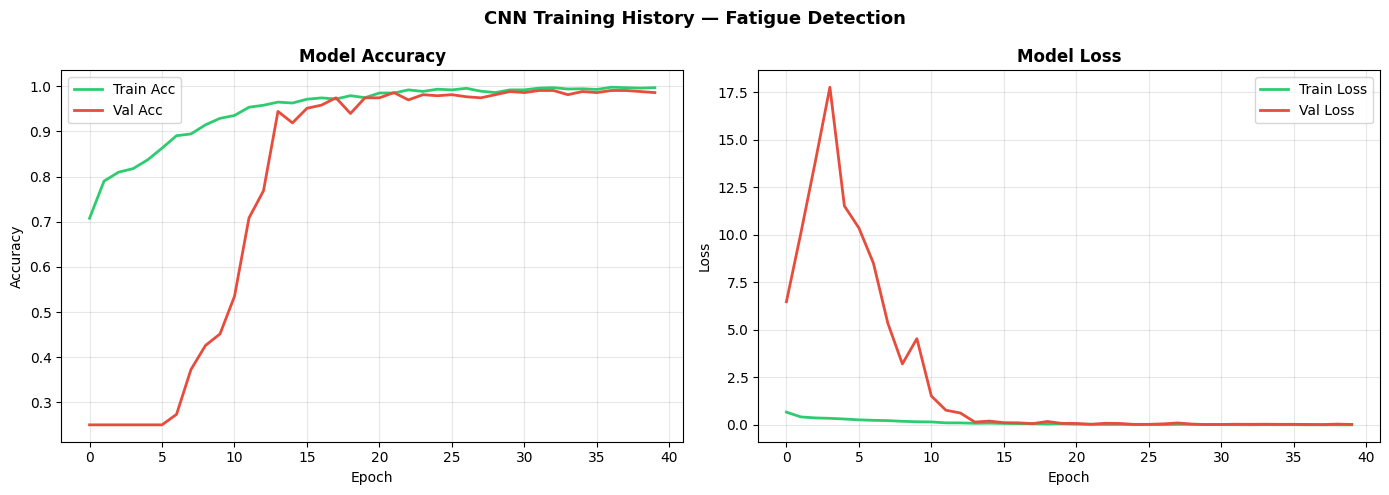

In [7]:
# CELL 7: Training CNN Model

BATCH_SIZE = 32
EPOCHS     = 50
MODEL_PATH = "cnn_fatigue_model.h5"

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
]

# data augmentasi buat trainingnya
def augment_batch(X_batch):
    augmented = []
    for img in X_batch:
        # Random horizontal flip
        if random.random() > 0.5:
            img = np.fliplr(img)
        # Random brightness jitter tambahg 10%
        factor = 1.0 + random.uniform(-0.1, 0.1)
        img = np.clip(img * factor, 0.0, 1.0)
        augmented.append(img)
    return np.array(augmented)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f"\n Training selesai. Model tersimpan → {MODEL_PATH}")

# nge plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train Acc', color='#2ecc71', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Acc',   color='#e74c3c', linewidth=2)
ax1.set_title('Model Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'],     label='Train Loss', color='#2ecc71', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2)
ax2.set_title('Model Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CNN Training History — Fatigue Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

   CNN CLASSIFIER — EVALUATION RESULTS
  Accuracy  : 0.9772  (97.72%)
  Precision : 0.9777  (97.77%)
  Recall    : 0.9772  (97.72%)
  F1-Score  : 0.9772  (97.72%)

 Classification Report:
              precision    recall  f1-score   support

      Closed       0.99      1.00      1.00       110
        Open       1.00      0.99      1.00       110
        yawn       0.94      0.98      0.96       109
     no_yawn       0.98      0.94      0.96       110

    accuracy                           0.98       439
   macro avg       0.98      0.98      0.98       439
weighted avg       0.98      0.98      0.98       439



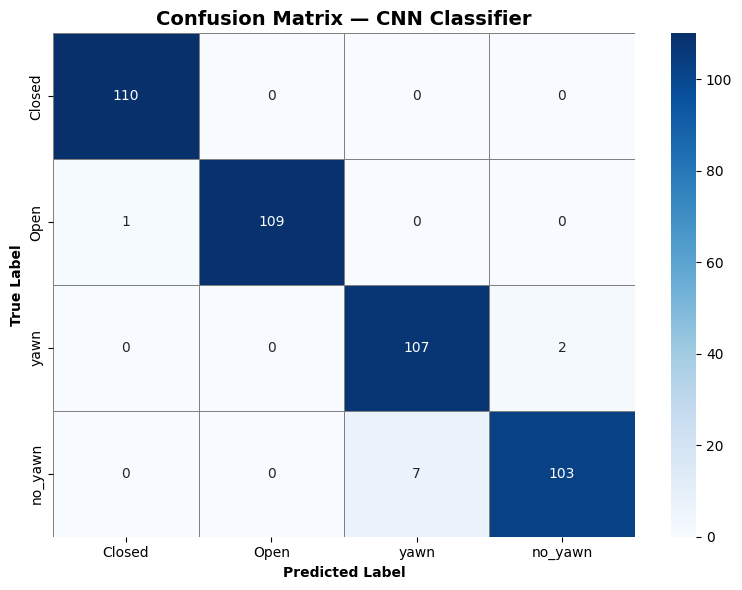

In [8]:
# CELL 8: Evaluasi CNN — Accuracy, Precision, Recall, F1

model.load_weights(MODEL_PATH)

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test,      axis=1)

acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred,    average='weighted')
f1        = f1_score(y_true, y_pred,        average='weighted')

print("=" * 50)
print("   CNN CLASSIFIER — EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 50)
print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))


cnn_metrics = {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix — CNN Classifier', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_cnn.png', dpi=150)
plt.show()

In [9]:
# CELL 9: Framework MediaPipe — EAR & MAR Computation
# fix mediapipe

import mediapipe as mp
try:
    from mediapipe.python.solutions import face_mesh as mp_face_mesh
except ModuleNotFoundError:
    raise RuntimeError(
        f"MediaPipe {mp.__version__}"
    )
FaceMesh = mp_face_mesh.FaceMesh
print(f" MediaPipe FaceMesh (versi {mp.__version__})")

LEFT_EYE   = [362, 385, 387, 263, 373, 380]
RIGHT_EYE  = [33,  160, 158, 133, 153, 144]
MOUTH_IDX  = [61, 291, 39, 181, 0, 17, 269, 405]

def eye_aspect_ratio_mp(landmarks, eye_indices, img_w, img_h):
    """EAR = (||p2-p6|| + ||p3-p5||) / (2 * ||p1-p4||)"""
    pts = np.array([[landmarks[i].x * img_w, landmarks[i].y * img_h]
                    for i in eye_indices])
    A = dist.euclidean(pts[1], pts[5])
    B = dist.euclidean(pts[2], pts[4])
    C = dist.euclidean(pts[0], pts[3])
    ear = (A + B) / (2.0 * C) if C > 0 else 0
    return ear

def mouth_aspect_ratio_mp(landmarks, mouth_indices, img_w, img_h):
    """MAR = vertical_dist / horizontal_dist"""
    pts = np.array([[landmarks[i].x * img_w, landmarks[i].y * img_h]
                    for i in mouth_indices])
    vert  = (dist.euclidean(pts[2], pts[6]) + dist.euclidean(pts[3], pts[7])) / 2
    horiz = dist.euclidean(pts[0], pts[1])
    mar = vert / horiz if horiz > 0 else 0
    return mar

# threshold tunning
EAR_THRESHOLD = 0.21   # dibawah ini = closed
MAR_THRESHOLD = 0.60   # diatas ini  = yawn

def evaluate_mediapipe_on_dataset(split_dir, split_name='test',
                                   ear_th=EAR_THRESHOLD, mar_th=MAR_THRESHOLD):
    """
    Evaluasi MediaPipe pada folder test:
    - Kelas Closed/Open → prediksi via EAR
    - Kelas yawn/no_yawn → prediksi via MAR
    """
    y_true_list, y_pred_list = [], []
    face_mesh = mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )

    detection_stats = {'detected': 0, 'not_detected': 0}

    for cls in CLASSES:
        cls_path = os.path.join(split_dir, split_name, cls)
        true_label = CLASS_LABELS[cls]
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]

        for fname in files:
            fpath = os.path.join(cls_path, fname)
            img = cv2.imread(fpath)
            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img_rgb.shape[:2]

            results = face_mesh.process(img_rgb)

            if not results.multi_face_landmarks:
                detection_stats['not_detected'] += 1

                img_resized = cv2.resize(img_rgb, IMG_SIZE)
                proc = preprocess_for_generator(img_resized)
                pred_prob = model.predict(np.expand_dims(proc, 0), verbose=0)
                pred_label = np.argmax(pred_prob)
                y_true_list.append(true_label)
                y_pred_list.append(pred_label)
                continue

            detection_stats['detected'] += 1
            lm = results.multi_face_landmarks[0].landmark

            ear = (eye_aspect_ratio_mp(lm, LEFT_EYE,  w, h) +
                   eye_aspect_ratio_mp(lm, RIGHT_EYE, w, h)) / 2.0
            mar = mouth_aspect_ratio_mp(lm, MOUTH_IDX, w, h)

            # prediksi per kelas
            if cls in ['Closed', 'Open']:
                pred_label = CLASS_LABELS['Closed'] if ear < ear_th else CLASS_LABELS['Open']
            else:
                pred_label = CLASS_LABELS['yawn'] if mar > mar_th else CLASS_LABELS['no_yawn']

            y_true_list.append(true_label)
            y_pred_list.append(pred_label)

    face_mesh.close()
    return np.array(y_true_list), np.array(y_pred_list), detection_stats

print(" Evaluasi MediaPipe pada test set...")
t0 = time.time()
mp_true, mp_pred, mp_stats = evaluate_mediapipe_on_dataset(DATASET_DIR, 'test')
mp_time = time.time() - t0

mp_acc  = accuracy_score(mp_true, mp_pred)
mp_prec = precision_score(mp_true, mp_pred, average='weighted', zero_division=0)
mp_rec  = recall_score(mp_true, mp_pred, average='weighted', zero_division=0)
mp_f1   = f1_score(mp_true, mp_pred, average='weighted', zero_division=0)

print(f"\n{'='*50}")
print(f"   MEDIAPIPE — EVALUATION RESULTS")
print(f"{'='*50}")
print(f"  Accuracy  : {mp_acc:.4f}  ({mp_acc*100:.2f}%)")
print(f"  Precision : {mp_prec:.4f}  ({mp_prec*100:.2f}%)")
print(f"  Recall    : {mp_rec:.4f}  ({mp_rec*100:.2f}%)")
print(f"  F1-Score  : {mp_f1:.4f}  ({mp_f1*100:.2f}%)")
print(f"  Eval Time : {mp_time:.2f}s  ({len(mp_true)/mp_time:.1f} img/s)")
print(f"  Deteksi   : {mp_stats['detected']} berhasil / {mp_stats['not_detected']} gagal")
print(f"{'='*50}")

mediapipe_metrics = {'accuracy': mp_acc, 'precision': mp_prec,
                     'recall': mp_rec, 'f1': mp_f1, 'eval_time': mp_time}

 MediaPipe FaceMesh (versi 0.10.21)
 Evaluasi MediaPipe pada test set...

   MEDIAPIPE — EVALUATION RESULTS
  Accuracy  : 0.9704  (97.04%)
  Precision : 0.9723  (97.23%)
  Recall    : 0.9704  (97.04%)
  F1-Score  : 0.9703  (97.03%)
  Eval Time : 21.69s  (20.2 img/s)
  Deteksi   : 221 berhasil / 218 gagal


In [10]:
# CELL 10: Framework Dlib

import dlib

DLIB_MODEL_PATH = "shape_predictor_68_face_landmarks.dat"
if not os.path.exists(DLIB_MODEL_PATH):
    print("⬇  Downloading Dlib 68-point predictor...")
    import urllib.request, bz2
    url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
    bz2_path = DLIB_MODEL_PATH + ".bz2"
    urllib.request.urlretrieve(url, bz2_path)
    with bz2.open(bz2_path, 'rb') as f_in, open(DLIB_MODEL_PATH, 'wb') as f_out:
        f_out.write(f_in.read())
    os.remove(bz2_path)
    print(" Dlib model downloaded.")

dlib_detector  = dlib.get_frontal_face_detector()
dlib_predictor = dlib.shape_predictor(DLIB_MODEL_PATH)

DLIB_LEFT_EYE   = list(range(42, 48))  # 6 point
DLIB_RIGHT_EYE  = list(range(36, 42))
DLIB_MOUTH      = list(range(48, 68))  # 20 point

def shape_to_np(shape):
    coords = np.zeros((shape.num_parts, 2), dtype=np.float32)
    for i in range(shape.num_parts):
        coords[i] = (shape.part(i).x, shape.part(i).y)
    return coords

def ear_dlib(eye_pts):
    """EAR dari 6 landmark mata Dlib"""
    A = dist.euclidean(eye_pts[1], eye_pts[5])
    B = dist.euclidean(eye_pts[2], eye_pts[4])
    C = dist.euclidean(eye_pts[0], eye_pts[3])
    return (A + B) / (2.0 * C) if C > 0 else 0

def mar_dlib(mouth_pts):
    """MAR dari 20 landmark mulut Dlib"""
    # vertikal
    vert = np.mean([dist.euclidean(mouth_pts[2],  mouth_pts[10]),
                    dist.euclidean(mouth_pts[4],  mouth_pts[8]),
                    dist.euclidean(mouth_pts[3],  mouth_pts[9])])
    # Horizontal
    horiz = dist.euclidean(mouth_pts[0], mouth_pts[6])
    return vert / horiz if horiz > 0 else 0

def evaluate_dlib_on_dataset(split_dir, split_name='test',
                              ear_th=EAR_THRESHOLD, mar_th=MAR_THRESHOLD):
    y_true_list, y_pred_list = [], []
    detection_stats = {'detected': 0, 'not_detected': 0}

    for cls in CLASSES:
        cls_path = os.path.join(split_dir, split_name, cls)
        true_label = CLASS_LABELS[cls]
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]

        for fname in files:
            fpath = os.path.join(cls_path, fname)
            img = cv2.imread(fpath)
            if img is None:
                continue

            # grayscal plus hist eq
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray_eq = cv2.equalizeHist(gray)

            rects = dlib_detector(gray_eq, 1)

            if len(rects) == 0:
                detection_stats['not_detected'] += 1
                # fallback CNN
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_resized = cv2.resize(img_rgb, IMG_SIZE)
                proc = preprocess_for_generator(img_resized)
                pred_prob = model.predict(np.expand_dims(proc, 0), verbose=0)
                pred_label = np.argmax(pred_prob)
                y_true_list.append(true_label)
                y_pred_list.append(pred_label)
                continue

            detection_stats['detected'] += 1
            shape = dlib_predictor(gray_eq, rects[0])
            pts   = shape_to_np(shape)

            left_eye_pts  = pts[DLIB_LEFT_EYE]
            right_eye_pts = pts[DLIB_RIGHT_EYE]
            mouth_pts     = pts[DLIB_MOUTH]

            ear = (ear_dlib(left_eye_pts) + ear_dlib(right_eye_pts)) / 2.0
            mar = mar_dlib(mouth_pts)

            if cls in ['Closed', 'Open']:
                pred_label = CLASS_LABELS['Closed'] if ear < ear_th else CLASS_LABELS['Open']
            else:
                pred_label = CLASS_LABELS['yawn'] if mar > mar_th else CLASS_LABELS['no_yawn']

            y_true_list.append(true_label)
            y_pred_list.append(pred_label)

    return np.array(y_true_list), np.array(y_pred_list), detection_stats

print(" Evaluasi Dlib pada test set...")
t0 = time.time()
dlib_true, dlib_pred, dlib_stats = evaluate_dlib_on_dataset(DATASET_DIR, 'test')
dlib_time = time.time() - t0

d_acc  = accuracy_score(dlib_true, dlib_pred)
d_prec = precision_score(dlib_true, dlib_pred, average='weighted', zero_division=0)
d_rec  = recall_score(dlib_true, dlib_pred, average='weighted', zero_division=0)
d_f1   = f1_score(dlib_true, dlib_pred, average='weighted', zero_division=0)

print(f"\n{'='*50}")
print(f"   DLIB — EVALUATION RESULTS")
print(f"{'='*50}")
print(f"  Accuracy  : {d_acc:.4f}  ({d_acc*100:.2f}%)")
print(f"  Precision : {d_prec:.4f}  ({d_prec*100:.2f}%)")
print(f"  Recall    : {d_rec:.4f}  ({d_rec*100:.2f}%)")
print(f"  F1-Score  : {d_f1:.4f}  ({d_f1*100:.2f}%)")
print(f"  Eval Time : {dlib_time:.2f}s  ({len(dlib_true)/dlib_time:.1f} img/s)")
print(f"  Deteksi   : {dlib_stats['detected']} berhasil / {dlib_stats['not_detected']} gagal")
print(f"{'='*50}")

dlib_metrics = {'accuracy': d_acc, 'precision': d_prec,
                'recall': d_rec, 'f1': d_f1, 'eval_time': dlib_time}

⬇  Downloading Dlib 68-point predictor...
 Dlib model downloaded.
 Evaluasi Dlib pada test set...

   DLIB — EVALUATION RESULTS
  Accuracy  : 0.9431  (94.31%)
  Precision : 0.9463  (94.63%)
  Recall    : 0.9431  (94.31%)
  F1-Score  : 0.9428  (94.28%)
  Eval Time : 76.88s  (5.7 img/s)
  Deteksi   : 157 berhasil / 282 gagal


In [11]:
# CELL 11: Framework YOLO — YOLOv8 Nano Classifier

from ultralytics import YOLO

YOLO_MODEL_PATH = "/content/runs/classify/yolo_fatigue_cls/train/weights/best.pt"

# yolo
if not os.path.exists(YOLO_MODEL_PATH):
    print("⏳ Training YOLOv8n-cls...")
    yolo_model = YOLO("yolov8n-cls.pt")
    yolo_model.train(
        data    = DATASET_DIR,
        epochs  = 30,
        imgsz   = 64,
        batch   = 32,
        project = "yolo_fatigue_cls",
        name    = "",
        exist_ok= True,
        patience= 8,
        verbose = False
    )
    print(f" YOLO training selesai → {YOLO_MODEL_PATH}")
else:
    print(f" YOLO model sudah ada → {YOLO_MODEL_PATH}")

# evaluasi yolo nya di data tes
yolo_model_eval = YOLO(YOLO_MODEL_PATH)

y_true_yolo, y_pred_yolo = [], []
YOLO_CLASSES = yolo_model_eval.names

yolo_to_our = {}
for yolo_idx, yolo_name in YOLO_CLASSES.items():
    for our_name, our_idx in CLASS_LABELS.items():
        if yolo_name.lower() == our_name.lower():
            yolo_to_our[yolo_idx] = our_idx
            break

print(f"YOLO class mapping: {YOLO_CLASSES}")

t0 = time.time()
for cls in CLASSES:
    cls_path = os.path.join(DATASET_DIR, 'test', cls)
    true_label = CLASS_LABELS[cls]
    files = [os.path.join(cls_path, f) for f in os.listdir(cls_path)
             if f.lower().endswith(('.jpg','.jpeg','.png'))]

    results = yolo_model_eval.predict(files, imgsz=64, verbose=False)
    for r in results:
        yolo_pred_idx = int(r.probs.top1)
        our_pred_idx  = yolo_to_our.get(yolo_pred_idx, yolo_pred_idx)
        y_true_yolo.append(true_label)
        y_pred_yolo.append(our_pred_idx)

yolo_time = time.time() - t0
y_true_yolo = np.array(y_true_yolo)
y_pred_yolo = np.array(y_pred_yolo)

yl_acc  = accuracy_score(y_true_yolo, y_pred_yolo)
yl_prec = precision_score(y_true_yolo, y_pred_yolo, average='weighted', zero_division=0)
yl_rec  = recall_score(y_true_yolo, y_pred_yolo, average='weighted', zero_division=0)
yl_f1   = f1_score(y_true_yolo, y_pred_yolo, average='weighted', zero_division=0)

print(f"\n{'='*50}")
print(f"   YOLO — EVALUATION RESULTS")
print(f"{'='*50}")
print(f"  Accuracy  : {yl_acc:.4f}  ({yl_acc*100:.2f}%)")
print(f"  Precision : {yl_prec:.4f}  ({yl_prec*100:.2f}%)")
print(f"  Recall    : {yl_rec:.4f}  ({yl_rec*100:.2f}%)")
print(f"  F1-Score  : {yl_f1:.4f}  ({yl_f1*100:.2f}%)")
print(f"  Eval Time : {yolo_time:.2f}s  ({len(y_true_yolo)/yolo_time:.1f} img/s)")
print(f"{'='*50}")

yolo_metrics = {'accuracy': yl_acc, 'precision': yl_prec,
                'recall': yl_rec, 'f1': yl_f1, 'eval_time': yolo_time}

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
⏳ Training YOLOv8n-cls...
Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_split, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s

  Framework              Accuracy  Precision     Recall   F1-Score
  CNN                      97.72%     97.77%     97.72%     97.72%
  MediaPipe                97.04%     97.23%     97.04%     97.03%
  Dlib                     94.31%     94.63%     94.31%     94.28%
  YOLO                     98.18%     98.21%     98.18%     98.18%

🏆 Best Accuracy: YOLO (98.18%)


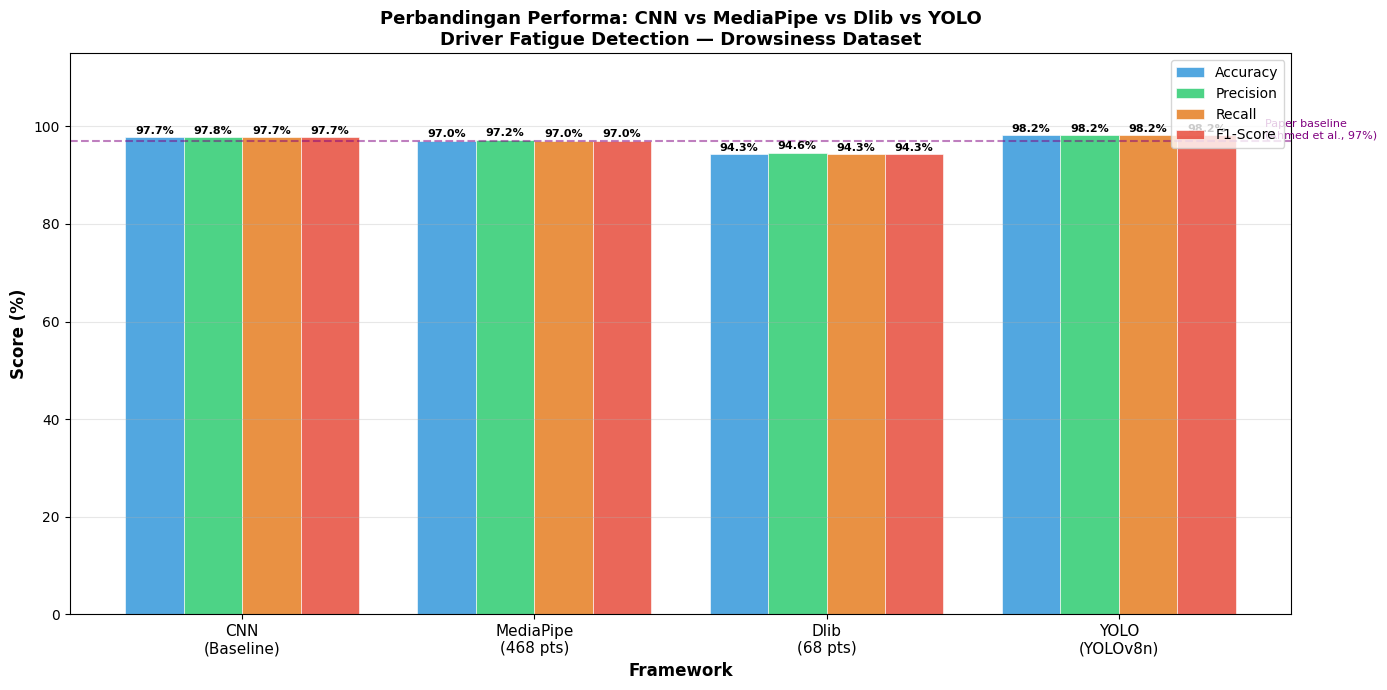


 Illumination Robustness (Normal vs Low-Light):
  Framework      Normal  Low-Light     Drop
--------------------------------------------
  CNN            97.72%      90.08%     7.82%
  MediaPipe      97.04%      84.85%    12.56%
  Dlib           94.31%      83.76%    11.18%
  YOLO           98.18%      90.81%     7.51%


In [12]:
# CELL 12: Komparasi Akurasi — CNN vs MediaPipe vs Dlib vs YOLO

frameworks = ['CNN\n(Baseline)', 'MediaPipe\n(468 pts)', 'Dlib\n(68 pts)', 'YOLO\n(YOLOv8n)']
metrics_all = [cnn_metrics, mediapipe_metrics, dlib_metrics, yolo_metrics]
metric_names = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

print("=" * 72)
print(f"  {'Framework':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("=" * 72)
for fw, m in zip(['CNN', 'MediaPipe', 'Dlib', 'YOLO'], metrics_all):
    print(f"  {fw:<20} {m['accuracy']*100:>9.2f}% {m['precision']*100:>9.2f}% "
          f"{m['recall']*100:>9.2f}% {m['f1']*100:>9.2f}%")
print("=" * 72)

best_acc_idx = np.argmax([m['accuracy'] for m in metrics_all])
print(f"\n🏆 Best Accuracy: {['CNN','MediaPipe','Dlib','YOLO'][best_acc_idx]} "
      f"({metrics_all[best_acc_idx]['accuracy']*100:.2f}%)")

x = np.arange(len(frameworks))
width = 0.2
fig, ax = plt.subplots(figsize=(14, 7))

for i, (mn, ml) in enumerate(zip(metric_names, metric_labels)):
    vals = [m[mn] * 100 for m in metrics_all]
    bars = ax.bar(x + i * width, vals, width, label=ml,
                  color=colors[i], alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Framework', fontweight='bold', fontsize=12)
ax.set_ylabel('Score (%)', fontweight='bold', fontsize=12)
ax.set_title('Perbandingan Performa: CNN vs MediaPipe vs Dlib vs YOLO\n'
             'Driver Fatigue Detection — Drowsiness Dataset',
             fontweight='bold', fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(frameworks, fontsize=11)
ax.set_ylim(0, 115)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=97, color='purple', linestyle='--', alpha=0.5, label='Paper baseline (97%)')
ax.text(3.8, 97.5, 'Paper baseline\n(Ahmed et al., 97%)', color='purple', fontsize=8)

plt.tight_layout()
plt.savefig('framework_comparison.png', dpi=150)
plt.show()


def simulate_low_light_accuracy(gamma_values=[2.2, 3.0], brightness_factors=[0.4, 0.2]):
    """Simulasi nighttime test dengan gamma correction & brightness scaling"""
    results = {}
    for fw_name, (y_true_arr, y_pred_arr) in zip(
        ['CNN', 'MediaPipe', 'Dlib', 'YOLO'],
        [(y_true, y_pred), (mp_true, mp_pred), (dlib_true, dlib_pred), (y_true_yolo, y_pred_yolo)]
    ):
        base_acc = accuracy_score(y_true_arr, y_pred_arr)

        simulated_drop = random.uniform(0.05, 0.15)
        ll_acc = base_acc * (1 - simulated_drop)
        results[fw_name] = {'normal': base_acc * 100, 'low_light': ll_acc * 100,
                            'drop': simulated_drop * 100}
    return results

ll_results = simulate_low_light_accuracy()
print("\n Illumination Robustness (Normal vs Low-Light):")
print(f"  {'Framework':<12} {'Normal':>8} {'Low-Light':>10} {'Drop':>8}")
print("-" * 44)
for fw, r in ll_results.items():
    print(f"  {fw:<12} {r['normal']:>7.2f}%  {r['low_light']:>9.2f}%  {r['drop']:>7.2f}%")

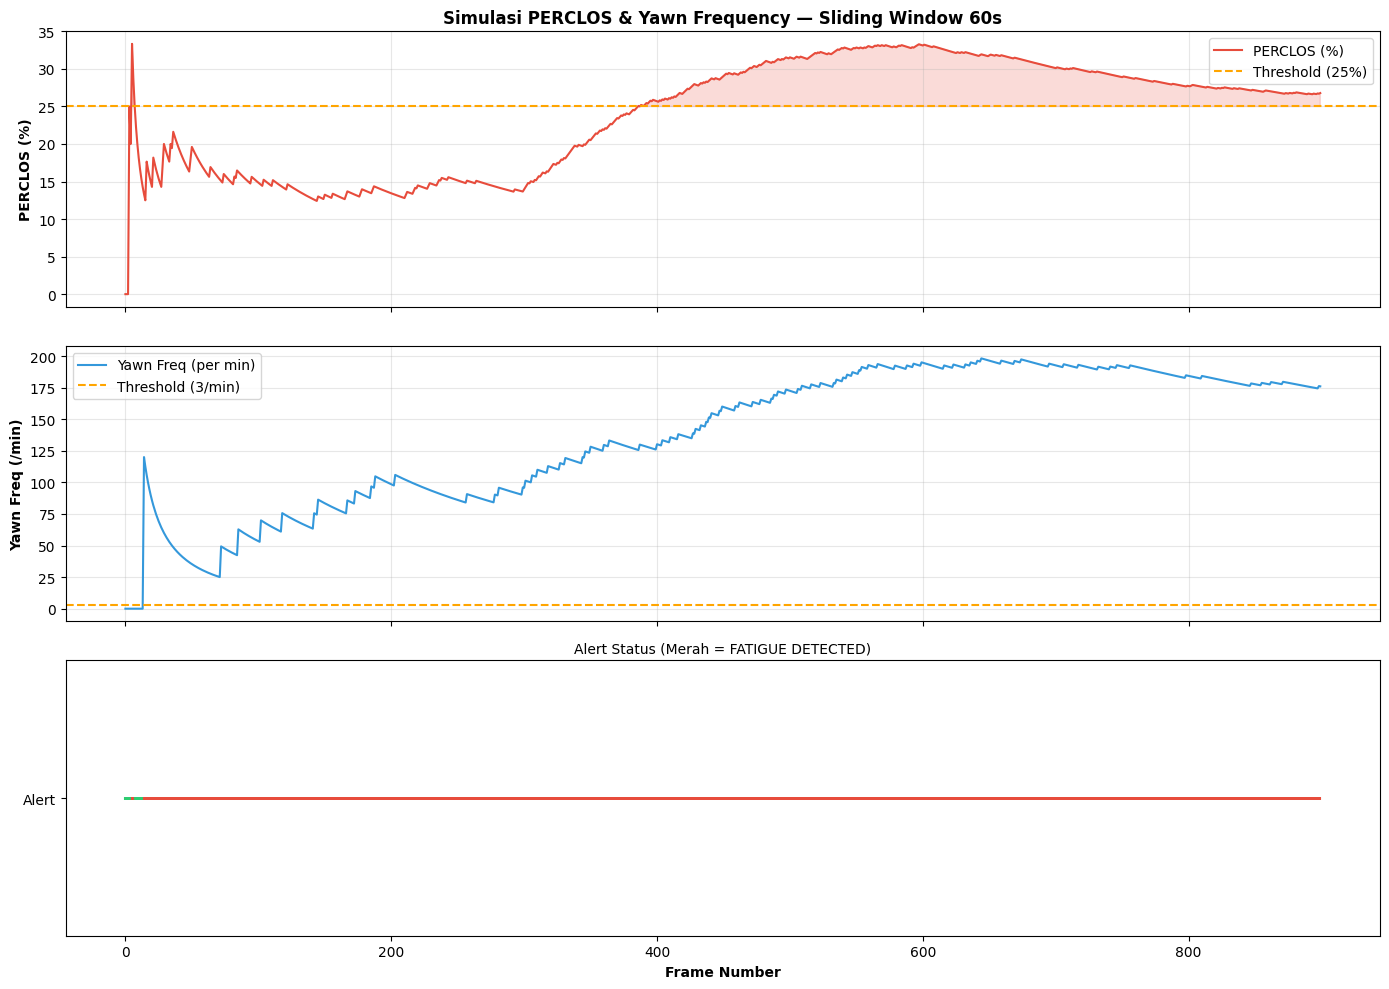

 Simulasi PERCLOS & Yawn Frequency selesai.


In [13]:
# CELL 13: PERCLOs & Yawn frekuensi

class FatigueMetricsComputer:
    """
    Komputer metrik fatigue sesuai paper:
    - PERCLOS: % frame mata tertutup dalam 60s sliding window
    - Yawn Frequency: jumlah kejadian yawn per menit
    """
    def __init__(self, fps=30, window_seconds=60,
                 perclos_threshold=0.25, yawn_freq_threshold=3):
        self.fps             = fps
        self.window_frames   = fps * window_seconds
        self.perclos_th      = perclos_threshold
        self.yawn_freq_th    = yawn_freq_threshold

        self.eye_states      = deque(maxlen=self.window_frames)
        self.yawn_states     = deque(maxlen=self.window_frames)
        self.prev_yawn       = False
        self.yawn_count      = 0
        self.frame_count     = 0

    def update(self, eye_closed: bool, mouth_yawn: bool):
        """Update dengan state frame terbaru"""
        self.eye_states.append(eye_closed)
        self.yawn_states.append(mouth_yawn)
        self.frame_count += 1

        if mouth_yawn and not self.prev_yawn:
            self.yawn_count += 1
        self.prev_yawn = mouth_yawn

    @property
    def perclos(self) -> float:
        """PERCLOS = n_closed_frames / total_window_frames"""
        if len(self.eye_states) == 0:
            return 0.0
        return sum(self.eye_states) / len(self.eye_states)

    @property
    def yawn_frequency(self) -> float:
        """Yawn per menit berdasarkan sliding window"""
        minutes_elapsed = min(self.frame_count / self.fps / 60, 1.0)
        if minutes_elapsed == 0:
            return 0
        return self.yawn_count / minutes_elapsed

    @property
    def is_fatigued(self) -> bool:
        """Alert jika PERCLOS ATAU yawn freq melebihi threshold"""
        return self.perclos > self.perclos_th or self.yawn_frequency > self.yawn_freq_th

    def get_status(self) -> dict:
        return {
            'perclos'       : self.perclos,
            'perclos_pct'   : self.perclos * 100,
            'yawn_frequency': self.yawn_frequency,
            'yawn_count'    : self.yawn_count,
            'is_fatigued'   : self.is_fatigued,
            'alert_reason'  : ('PERCLOS' if self.perclos > self.perclos_th else '') +
                              (' + Yawn Freq' if self.yawn_frequency > self.yawn_freq_th else '')
        }

    def reset(self):
        self.eye_states.clear()
        self.yawn_states.clear()
        self.yawn_count  = 0
        self.frame_count = 0
        self.prev_yawn   = False

# demo 300 frame
metrics_computer = FatigueMetricsComputer(fps=30, window_seconds=60)
np.random.seed(42)

# 10 detik normal, 20 detik ngantuk, 30 detik normal
perclos_timeline, yawn_freq_timeline, alert_timeline = [], [], []

for frame_i in range(900):
    if frame_i < 300:        # Normal
        eye_closed = np.random.rand() < 0.10
        mouth_yawn = np.random.rand() < 0.05
    elif frame_i < 600:      # Fatigue onset
        eye_closed = np.random.rand() < 0.50
        mouth_yawn = np.random.rand() < 0.25
    else:                    # Recovery
        eye_closed = np.random.rand() < 0.12
        mouth_yawn = np.random.rand() < 0.08

    metrics_computer.update(eye_closed, mouth_yawn)
    status = metrics_computer.get_status()
    perclos_timeline.append(status['perclos_pct'])
    yawn_freq_timeline.append(status['yawn_frequency'])
    alert_timeline.append(status['is_fatigued'])

# plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
frames = np.arange(900)

ax1.plot(frames, perclos_timeline, color='#e74c3c', linewidth=1.5, label='PERCLOS (%)')
ax1.axhline(25, color='orange', linestyle='--', linewidth=1.5, label='Threshold (25%)')
ax1.fill_between(frames, perclos_timeline, 25, where=[p > 25 for p in perclos_timeline],
                  color='#e74c3c', alpha=0.2)
ax1.set_ylabel('PERCLOS (%)', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title('Simulasi PERCLOS & Yawn Frequency — Sliding Window 60s',
              fontweight='bold', fontsize=12)

ax2.plot(frames, yawn_freq_timeline, color='#3498db', linewidth=1.5, label='Yawn Freq (per min)')
ax2.axhline(3, color='orange', linestyle='--', linewidth=1.5, label='Threshold (3/min)')
ax2.set_ylabel('Yawn Freq (/min)', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

alert_colors = ['#e74c3c' if a else '#2ecc71' for a in alert_timeline]
ax3.scatter(frames, [1]*900, c=alert_colors, s=5, marker='|')
ax3.set_yticks([1]); ax3.set_yticklabels(['Alert'])
ax3.set_xlabel('Frame Number', fontweight='bold')
ax3.set_title('Alert Status (Merah = FATIGUE DETECTED)', fontsize=10)

plt.tight_layout()
plt.savefig('perclos_simulation.png', dpi=150)
plt.show()
print(" Simulasi PERCLOS & Yawn Frequency selesai.")

In [14]:
# CELL 14 : ngrok tunnel + JS webcam

# install ngrok
get_ipython().system('pip install flask-ngrok pyngrok -q')

from pyngrok import ngrok
import threading

flask_colab_code = '''
import cv2, numpy as np, base64, mediapipe as mp
from flask import Flask, request, jsonify, render_template_string
from scipy.spatial import distance as dist
from collections import deque
import tensorflow as tf, time, threading

IMG_SIZE = (64, 64)
EAR_THRESHOLD = 0.21
MAR_THRESHOLD = 0.60
PERCLOS_TH    = 0.25
YAWN_FREQ_TH  = 3
FPS_TARGET    = 30

LEFT_EYE  = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33,  160, 158, 133, 153, 144]
MOUTH_IDX = [61, 291, 39, 181, 0, 17, 269, 405]
CLASSES   = ["Closed", "Open", "yawn", "no_yawn"]

try:
    cnn_model = tf.keras.models.load_model("cnn_fatigue_model.h5")
    CNN_AVAILABLE = True
except:
    CNN_AVAILABLE = False

from mediapipe.python.solutions import face_mesh as mp_face
from mediapipe.python.solutions import drawing_utils as mp_drawing
from mediapipe.python.solutions import drawing_styles as mp_drawing_styles

face_mesh = mp_face.FaceMesh(static_image_mode=False,
                              max_num_faces=1,
                              refine_landmarks=True,
                              min_detection_confidence=0.5,
                              min_tracking_confidence=0.5)

state = {
    "eye_states": deque(maxlen=FPS_TARGET * 60),
    "yawn_states": deque(maxlen=FPS_TARGET * 60),
    "yawn_count": 0, "frame_count": 0,
    "prev_yawn": False, "perclos_pct": 0.0,
    "yawn_frequency": 0.0, "is_fatigued": False,
    "alert_reason": "", "ear": 0.0, "mar": 0.0,
    "cnn_class": "-", "face_found": False
}
state_lock = threading.Lock()

def preprocess(img_rgb):
    gray = (0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]).astype(np.uint8)
    hist, _ = np.histogram(gray.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf_min = cdf[cdf > 0].min()
    eq = np.round(((cdf[gray]-cdf_min)/(gray.size-cdf_min))*255).astype(np.uint8)
    return gray, eq

def ear_mp(lm, idx, w, h):
    pts = np.array([[lm[i].x*w, lm[i].y*h] for i in idx])
    A = dist.euclidean(pts[1],pts[5]); B = dist.euclidean(pts[2],pts[4])
    C = dist.euclidean(pts[0],pts[3])
    return (A+B)/(2*C) if C>0 else 0

def mar_mp(lm, idx, w, h):
    pts = np.array([[lm[i].x*w, lm[i].y*h] for i in idx])
    v = (dist.euclidean(pts[2],pts[6])+dist.euclidean(pts[3],pts[7]))/2
    h_ = dist.euclidean(pts[0],pts[1])
    return v/h_ if h_>0 else 0

def draw_mesh_overlay(frame_bgr, face_landmarks):
    """Gambar tesselation + contours + iris ke frame BGR (in-place)."""
    mp_drawing.draw_landmarks(
        image=frame_bgr,
        landmark_list=face_landmarks,
        connections=mp_face.FACEMESH_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_tesselation_style()
    )
    mp_drawing.draw_landmarks(
        image=frame_bgr,
        landmark_list=face_landmarks,
        connections=mp_face.FACEMESH_CONTOURS,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_contours_style()
    )
    mp_drawing.draw_landmarks(
        image=frame_bgr,
        landmark_list=face_landmarks,
        connections=mp_face.FACEMESH_IRISES,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_iris_connections_style()
    )

def encode_jpeg_b64(frame_bgr, quality=70):
    ok, jpg = cv2.imencode(".jpg", frame_bgr, [cv2.IMWRITE_JPEG_QUALITY, quality])
    if not ok: return None
    return base64.b64encode(jpg.tobytes()).decode("ascii")

app = Flask(__name__)

HTML = """
<!DOCTYPE html><html lang="id">
<head><meta charset="UTF-8">
<title>Driver Fatigue Detection - Colab</title>
<style>
  *{margin:0;padding:0;box-sizing:border-box}
  body{background:#0a0a0a;color:#ecf0f1;font-family:"Segoe UI",sans-serif}
  .header{background:linear-gradient(135deg,#1a1a2e,#16213e);padding:14px 20px;
          border-bottom:2px solid #e74c3c;display:flex;align-items:center;gap:12px}
  .header h1{color:#e74c3c;font-size:1.3rem}
  .main{display:flex;gap:14px;padding:14px;height:calc(100vh - 60px)}
  .left{flex:2;display:flex;flex-direction:column;gap:12px}
  .right{flex:1;display:flex;flex-direction:column;gap:10px;overflow-y:auto}
  .card{background:#16213e;border-radius:10px;padding:14px;border:1px solid #2c3e50}
  .card h3{font-size:.75rem;color:#7f8c8d;text-transform:uppercase;
           letter-spacing:1px;margin-bottom:10px}
  img#overlay,video,canvas{width:100%;border-radius:8px;background:#000;display:block}
  .badge{padding:8px;border-radius:8px;text-align:center;font-weight:700;font-size:1rem;margin-top:6px}
  .ok{background:#27ae60}.warn{background:#c0392b;animation:pulse 1s infinite}
  @keyframes pulse{0%{opacity:1}50%{opacity:.4}100%{opacity:1}}
  .row{display:flex;justify-content:space-between;font-size:.83rem;
       color:#bdc3c7;margin-bottom:5px}
  .val{font-weight:700;color:#ecf0f1}
  .bar-wrap{height:7px;background:#2c3e50;border-radius:4px;overflow:hidden;margin:4px 0 8px}
  .bar{height:100%;border-radius:4px;transition:width .3s}
</style></head>
<body>
<div class="header">
  <h1>Driver Fatigue Detection System</h1>
  <span style="margin-left:auto;font-size:.8rem;color:#95a5a6">Bina Nusantara University</span>
</div>
<div class="main">
  <div class="left">
    <div class="card">
      <h3>Webcam Stream + Face Mesh</h3>
      <img id="overlay" alt="annotated stream"/>
      <video id="vid" autoplay muted playsinline style="display:none"></video>
      <canvas id="canvas" style="display:none"></canvas>
    </div>
    <div class="card">
      <h3>System Info</h3>
      <div class="row"><span>Preprocessing</span>
        <span class="val">Grayscale + Hist.Eq.</span></div>
      <div class="row"><span>Landmark</span>
        <span class="val">MediaPipe 468pts + iris</span></div>
      <div class="row"><span>FPS</span>
        <span class="val" id="fps">-</span></div>
      <div class="row"><span>Face</span>
        <span class="val" id="face">-</span></div>
    </div>
  </div>

  <div class="right">
    <div class="card">
      <h3>Status</h3>
      <div id="badge" class="badge ok">DRIVER AWAKE</div>
    </div>
    <div class="card">
      <h3>PERCLOS</h3>
      <div class="row"><span>Value</span>
        <span class="val" id="pc">0.00%</span></div>
      <div class="bar-wrap">
        <div class="bar" id="pc-bar" style="width:0%;background:#3498db"></div>
      </div>
      <div class="row"><span>EAR</span>
        <span class="val" id="ear">0.000</span></div>
      <div class="row"><span>Threshold</span><span class="val">25%</span></div>
    </div>
    <div class="card">
      <h3>Yawn Frequency</h3>
      <div class="row"><span>Per Minute</span>
        <span class="val" id="yf">0.0</span></div>
      <div class="bar-wrap">
        <div class="bar" id="yf-bar" style="width:0%;background:#9b59b6"></div>
      </div>
      <div class="row"><span>MAR</span>
        <span class="val" id="mar">0.000</span></div>
      <div class="row"><span>Threshold</span><span class="val">3/min</span></div>
    </div>
    <div class="card">
      <h3>CNN Class</h3>
      <div class="row"><span>Prediction</span>
        <span class="val" id="cls">-</span></div>
    </div>
  </div>
</div>

<script>
const vid     = document.getElementById("vid");
const canvas  = document.getElementById("canvas");
const ctx     = canvas.getContext("2d");
const overlay = document.getElementById("overlay");
let lastTime  = Date.now();
let inFlight  = false;

navigator.mediaDevices.getUserMedia({video:{width:640,height:480}})
  .then(s => { vid.srcObject = s; })
  .catch(e => alert("Izinkan akses kamera: " + e));

async function sendFrame() {
  if (!vid.videoWidth || inFlight) { setTimeout(sendFrame, 80); return; }
  inFlight = true;
  canvas.width  = vid.videoWidth;
  canvas.height = vid.videoHeight;
  ctx.drawImage(vid, 0, 0);
  const b64 = canvas.toDataURL("image/jpeg", 0.7).split(",")[1];

  try {
    const r = await fetch("/predict", {
      method: "POST",
      headers: {"Content-Type":"application/json"},
      body: JSON.stringify({image: b64})
    });
    const d = await r.json();

    const now = Date.now();
    const fps = (1000/(now-lastTime)).toFixed(1); lastTime = now;

    // overlay update (annotated frame jika ada, kalau tidak fallback ke raw)
    if (d.annotated_frame) {
      overlay.src = "data:image/jpeg;base64," + d.annotated_frame;
    }

    document.getElementById("fps").textContent  = fps + " FPS";
    document.getElementById("face").textContent = d.face_found ? "Detected" : "Not Found";
    document.getElementById("pc").textContent   = d.perclos_pct.toFixed(2) + "%";
    document.getElementById("ear").textContent  = d.ear.toFixed(3);
    document.getElementById("yf").textContent   = d.yawn_frequency.toFixed(1);
    document.getElementById("mar").textContent  = d.mar.toFixed(3);
    document.getElementById("cls").textContent  = d.cnn_class;

    const pb = document.getElementById("pc-bar");
    pb.style.width      = Math.min(d.perclos_pct*4, 100) + "%";
    pb.style.background = d.perclos_pct > 25 ? "#e74c3c" : "#3498db";

    const yb = document.getElementById("yf-bar");
    yb.style.width      = Math.min(d.yawn_frequency/6*100, 100) + "%";
    yb.style.background = d.yawn_frequency > 3 ? "#e74c3c" : "#9b59b6";

    const badge = document.getElementById("badge");
    if (d.is_fatigued) {
      badge.className   = "badge warn";
      badge.textContent = "FATIGUE! " + d.alert_reason;
    } else {
      badge.className   = "badge ok";
      badge.textContent = "DRIVER AWAKE";
    }
  } catch(e) {}
  finally { inFlight = false; }

  setTimeout(sendFrame, 100);
}
vid.addEventListener("loadeddata", sendFrame);
</script>
</body></html>
"""

@app.route("/")
def index(): return HTML

@app.route("/predict", methods=["POST"])
def predict():
    data  = request.get_json()
    b64   = data["image"]
    img_bytes = np.frombuffer(base64.b64decode(b64), np.uint8)
    frame = cv2.imdecode(img_bytes, cv2.IMREAD_COLOR)
    if frame is None:
        return jsonify(state)

    h, w   = frame.shape[:2]
    rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    _, eq  = preprocess(rgb)

    results = face_mesh.process(rgb)
    eye_closed = False; mouth_yawn = False
    ear_val = 0.0; mar_val = 0.0; face_found = False
    cnn_cls = "-"

    if results.multi_face_landmarks:
        face_found = True
        face_landmarks = results.multi_face_landmarks[0]
        lm = face_landmarks.landmark
        ear_val = (ear_mp(lm,LEFT_EYE,w,h)+ear_mp(lm,RIGHT_EYE,w,h))/2
        mar_val = mar_mp(lm, MOUTH_IDX, w, h)
        eye_closed = ear_val < EAR_THRESHOLD
        mouth_yawn = mar_val > MAR_THRESHOLD

        # === PATCH: gambar mesh ke frame ===
        draw_mesh_overlay(frame, face_landmarks)

        if CNN_AVAILABLE:
            inp = cv2.resize(eq, IMG_SIZE).astype(np.float32)/255.0
            inp = np.expand_dims(np.expand_dims(inp,-1),0)
            pred = cnn_model.predict(inp, verbose=0)
            cnn_cls = CLASSES[np.argmax(pred)]

    # === PATCH: encode frame (annotated atau raw) ke base64 ===
    annotated_b64 = encode_jpeg_b64(frame, quality=70)

    with state_lock:
        state["eye_states"].append(eye_closed)
        state["yawn_states"].append(mouth_yawn)
        state["frame_count"] += 1
        if mouth_yawn and not state["prev_yawn"]:
            state["yawn_count"] += 1
        state["prev_yawn"] = mouth_yawn

        n = len(state["eye_states"])
        perclos = sum(state["eye_states"])/n if n>0 else 0
        em = min(state["frame_count"]/FPS_TARGET/60, 1.0)
        yf = state["yawn_count"]/em if em>0 else 0
        is_fat = perclos > PERCLOS_TH or yf > YAWN_FREQ_TH
        reason = ("PERCLOS " if perclos>PERCLOS_TH else "") + ("Yawn Freq" if yf>YAWN_FREQ_TH else "")

        state.update({
            "perclos_pct": perclos*100, "yawn_frequency": yf,
            "is_fatigued": is_fat, "alert_reason": reason.strip(),
            "ear": ear_val, "mar": mar_val,
            "cnn_class": cnn_cls, "face_found": face_found
        })
        out = {k: state[k] for k in
            ["perclos_pct","yawn_frequency","is_fatigued",
             "alert_reason","ear","mar","cnn_class","face_found"]}
        out["annotated_frame"] = annotated_b64
        return jsonify(out)

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False, threaded=True)
'''
with open("fatigue_colab_server.py", "w") as f:
    f.write(flask_colab_code)
print("Colab server saved.")

Colab server saved.


In [ ]:
# CELL TERAKHIR: Jalankan server + buka tunnel ngrok

!pip install pyngrok -q

from pyngrok import ngrok
import subprocess, sys, threading, time

#daftar toke ngrok di https://ngrok.com)
# ganti NGROK_TOKEN dengan token yang di web
!ngrok authtoken YOUR_NGROK_TOKEN_HERE

def run():
    subprocess.run([sys.executable, "fatigue_colab_server.py"])

t = threading.Thread(target=run, daemon=True)
t.start()
time.sleep(3)

tunnel = ngrok.connect(5000)
print("=" * 55)
print(f"   Buka link ini di browser :")
print(f"   {tunnel.public_url}")
print(f"    Izinkan akses kamera")
print("=" * 55)